# Notebook 2 — Modelling, Evaluation & SHAP
Loads the processed dataset, tunes and trains an XGBoost Regressor (predicting continuous Cognitive Score) and an XGBoost Classifier (predicting Low / Medium / High risk), evaluates both, and produces SHAP explainability plots.

In [5]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('..')

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                                accuracy_score, classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from xgboost import XGBRegressor, XGBClassifier

from config import PROC_DATA, MODELS_DIR, REPORTS_DIR, RANDOM_STATE, TEST_SIZE, N_TRIALS, CV_FOLDS

sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded.")

Libraries loaded.


## 1. Load Processed Data & Split

In [22]:
df = pl.read_csv(PROC_DATA).to_pandas()

# Check for leaking columns
print([col for col in df.columns if col not in
       ['Cognitive_Score', 'Risk_Level', 'User_ID']])

preprocessor = joblib.load(MODELS_DIR / 'preprocessor.pkl')

NUMERICAL_FEATURES = [
    'Age', 'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
    'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score',
    'Stress_Sleep_Interaction', 'Caffeine_Sleep_Ratio', 'Fatigue_Load'
]
CATEGORICAL_FEATURES = ['Gender', 'Diet_Type', 'Exercise_Frequency']
ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

X_raw = df[ALL_FEATURES]
y_reg = df['Cognitive_Score'].values

le = LabelEncoder()
y_clf = le.fit_transform(df['Risk_Level'])
print(f"Risk classes: {le.classes_}  →  encoded as {list(range(len(le.classes_)))}")

X = preprocessor.transform(X_raw)
print(f"Feature matrix shape: {X.shape}")

['Age', 'Gender', 'Sleep_Duration', 'Stress_Level', 'Diet_Type', 'Daily_Screen_Time', 'Exercise_Frequency', 'Caffeine_Intake', 'Reaction_Time', 'Memory_Test_Score', 'AI_Predicted_Score', 'Stress_Sleep_Interaction', 'Caffeine_Sleep_Ratio', 'Fatigue_Load']
Risk classes: ['High' 'Low' 'Medium']  →  encoded as [0, 1, 2]
Feature matrix shape: (80000, 19)


In [23]:
# Stratified split so each fold contains all three risk levels
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_clf
)
print(f"Train : {X_train.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

Train : 64,000
Test  : 16,000


## 2. XGBoost Regressor — Hyperparameter Optimisation

Optuna uses a TPE (Tree-structured Parzen Estimator) sampler — a Bayesian approach that learns from previous trials rather than searching randomly. We minimise RMSE over stratified cross-validation.

In [25]:
def objective_reg(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'tree_method'      : 'hist',
    }
    model = XGBRegressor(**params)
    try:
        rng = np.random.default_rng(RANDOM_STATE + trial.number)
        idx = rng.choice(len(X_train), size=int(len(X_train) * 0.4), replace=False)
        kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(model, X_train[idx], y_reg_train[idx],
                                 cv=kf, scoring='neg_root_mean_squared_error')
        result = -scores.mean()
        if np.isnan(result):
            return float('inf')
        return float(result)
    except Exception:
        return float('inf')

study_reg = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study_reg.optimize(objective_reg, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest RMSE   : {study_reg.best_value:.4f}")
print(f"Best params : {study_reg.best_params}")

Best trial: 94. Best value: 0.793505: 100%|██████████| 100/100 [11:06<00:00,  6.66s/it]


Best RMSE   : 0.7935
Best params : {'n_estimators': 958, 'max_depth': 6, 'learning_rate': 0.030319065456140267, 'subsample': 0.622715129289137, 'colsample_bytree': 0.9376147279330803, 'min_child_weight': 2, 'reg_alpha': 0.002710018127815877, 'reg_lambda': 0.001254588223795402}


## 3. Train Final Regressor

In [35]:
best_reg_params = {
    **study_reg.best_params,
    'random_state': RANDOM_STATE,
    'n_jobs'      : -1,
    'tree_method' : 'hist',
}

xgb_reg = XGBRegressor(**best_reg_params)
xgb_reg.fit(
    X_train, y_reg_train,
    eval_set=[(X_test, y_reg_test)],
    verbose=False
)

y_pred_reg = xgb_reg.predict(X_test)
mae  = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2   = r2_score(y_reg_test, y_pred_reg)

print("── Regressor Results ──────────────────")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")

── Regressor Results ──────────────────
  MAE  : 0.4758
  RMSE : 0.6360
  R²   : 0.9992


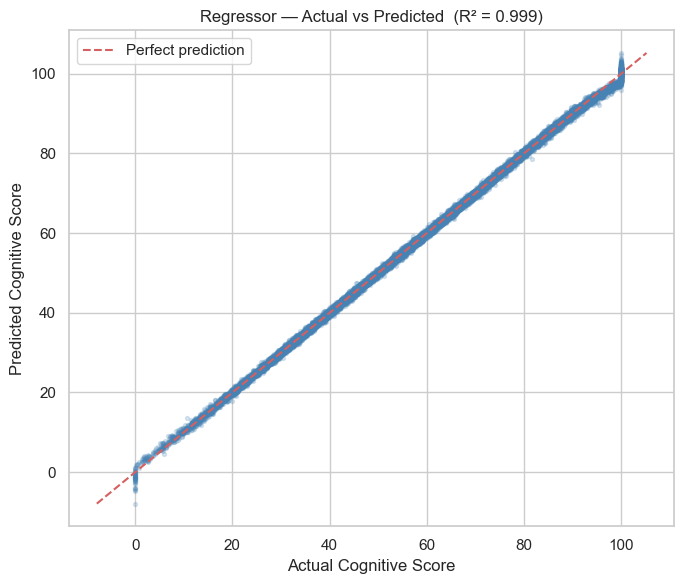

In [36]:
# Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, y_pred_reg, alpha=0.2, s=8, color='steelblue')
lims = [min(y_reg_test.min(), y_pred_reg.min()),
        max(y_reg_test.max(), y_pred_reg.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Cognitive Score')
plt.ylabel('Predicted Cognitive Score')
plt.title(f'Regressor — Actual vs Predicted  (R² = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'regressor_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. XGBoost Classifier (Risk Level)

Uses the same best hyperparameters from the regression study as a warm start — a practical shortcut since both tasks share the same feature set. The objective is switched to `multi:softmax` for three-class classification.

In [37]:
clf_params = {
    **study_reg.best_params,
    'random_state': RANDOM_STATE,
    'n_jobs'      : -1,
    'tree_method' : 'hist',
    'objective'   : 'multi:softmax',
    'num_class'   : 3,
    'eval_metric' : 'mlogloss',
}

xgb_clf = XGBClassifier(**clf_params)
xgb_clf.fit(
    X_train, y_clf_train,
    eval_set=[(X_test, y_clf_test)],
    verbose=False
)

y_pred_clf = xgb_clf.predict(X_test)
acc = accuracy_score(y_clf_test, y_pred_clf)

print("── Classifier Results ─────────────────")
print(f"  Accuracy : {acc:.4f}\n")
print(classification_report(y_clf_test, y_pred_clf, target_names=le.classes_))

── Classifier Results ─────────────────
  Accuracy : 0.9817

              precision    recall  f1-score   support

        High       0.99      0.99      0.99      5279
         Low       0.99      0.98      0.99      5282
      Medium       0.97      0.98      0.97      5439

    accuracy                           0.98     16000
   macro avg       0.98      0.98      0.98     16000
weighted avg       0.98      0.98      0.98     16000



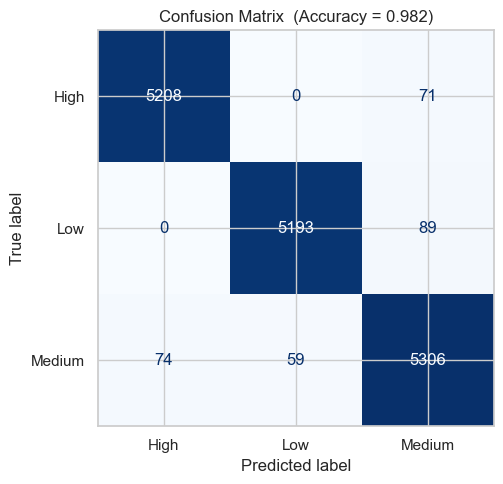

In [38]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_pred_clf,
    display_labels=le.classes_,
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'Confusion Matrix  (Accuracy = {acc:.3f})')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'classifier_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Analysis

`TreeExplainer` is exact and runs in milliseconds for XGBoost — no approximations.

- **Beeswarm** — global view: which features matter most and in which direction
- **Bar** — clean ranked importance summary
- **Waterfall** — local view: why the model gave one specific prediction

In [39]:
explainer = shap.TreeExplainer(xgb_reg)

# Sample 2000 test rows for faster rendering
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_test), size=2000, replace=False)
X_sample = X_test[sample_idx]
shap_values = explainer(X_sample)

# Attach readable feature names (including OHE-expanded categoricals)
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
shap_values.feature_names = NUMERICAL_FEATURES + cat_names
print("SHAP values computed.")

SHAP values computed.


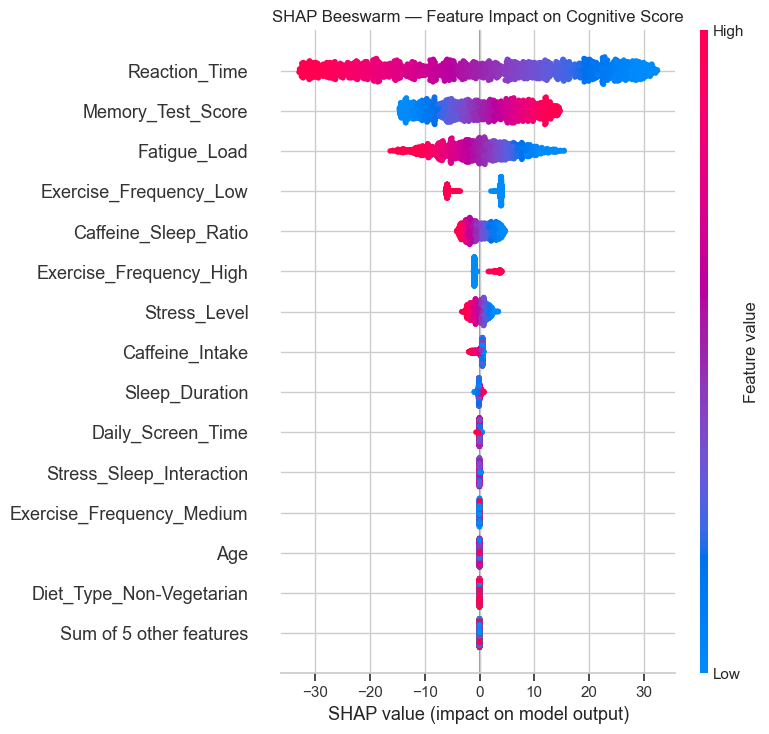

In [40]:
# Beeswarm — global feature importance
plt.figure()
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP Beeswarm — Feature Impact on Cognitive Score')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

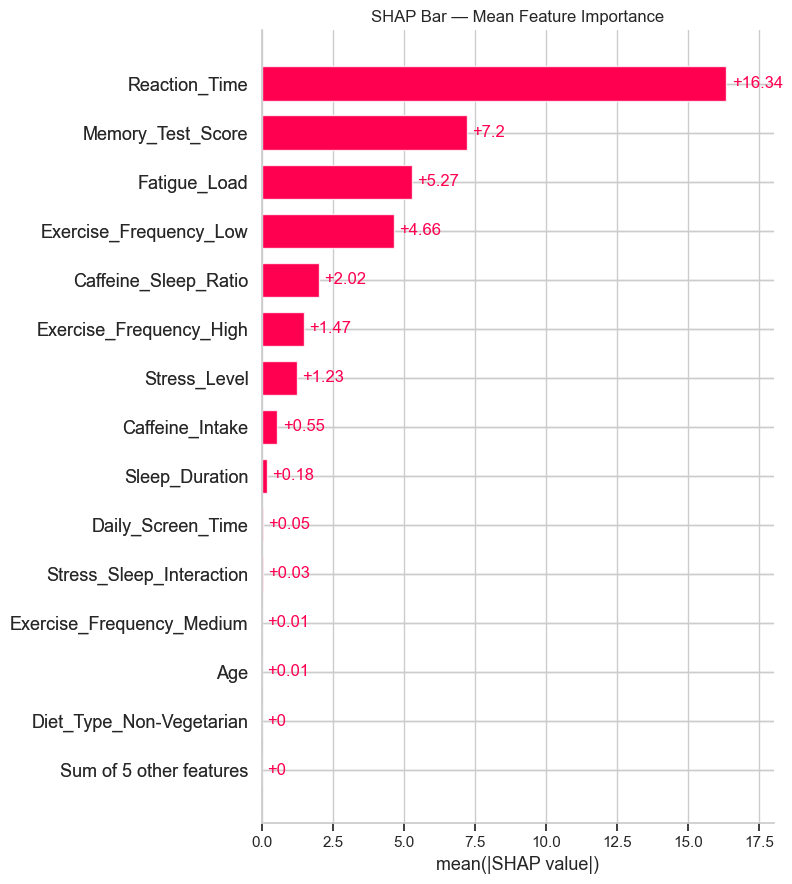

In [41]:
# Bar — mean absolute SHAP values
plt.figure()
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title('SHAP Bar — Mean Feature Importance')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

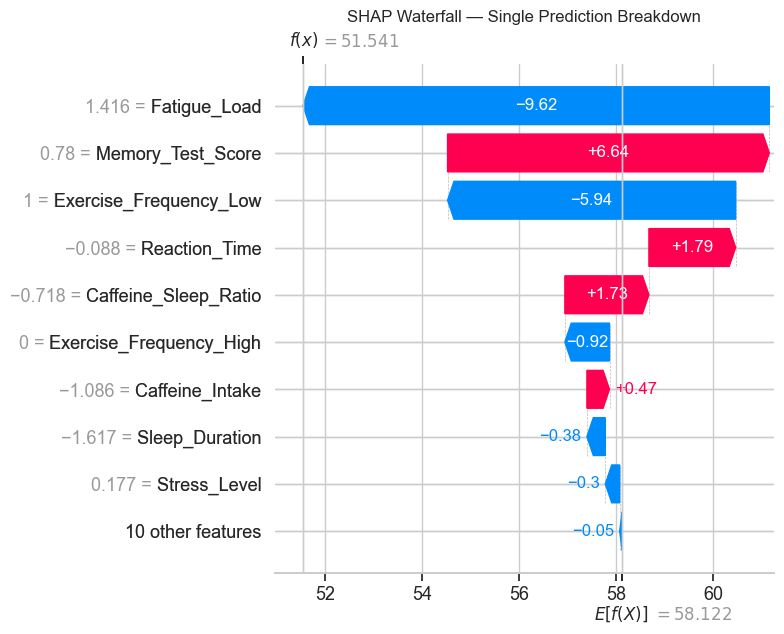

In [42]:
# Waterfall — single prediction breakdown
plt.figure()
shap.plots.waterfall(shap_values[0], show=False)
plt.title('SHAP Waterfall — Single Prediction Breakdown')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Models

In [43]:
xgb_reg.save_model(MODELS_DIR / 'xgb_regressor.ubj')
xgb_clf.save_model(MODELS_DIR / 'xgb_classifier.ubj')
joblib.dump(le, MODELS_DIR / 'label_encoder.pkl')

print("Saved:")
print(f"  {MODELS_DIR / 'xgb_regressor.ubj'}")
print(f"  {MODELS_DIR / 'xgb_classifier.ubj'}")
print(f"  {MODELS_DIR / 'label_encoder.pkl'}")

Saved:
  C:\Users\Atharv Chaudhary\PycharmProjects\AI-CIA-3\models\xgb_regressor.ubj
  C:\Users\Atharv Chaudhary\PycharmProjects\AI-CIA-3\models\xgb_classifier.ubj
  C:\Users\Atharv Chaudhary\PycharmProjects\AI-CIA-3\models\label_encoder.pkl
